In [1]:
from importlib import reload
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import einops

import dinov2

In [2]:
os.environ['DBXROOT'] = '/mnt/labshare/PERSONAL/dmitry/dbx'
os.environ['DBXVERBOSE'] = 'True'
os.environ['DBXDEBUG'] = 'True'

In [3]:
import autopath.gigaq.dinov2.pipelines
reload(autopath.gigaq.dinov2.pipelines)

/home/t-9dkarp/miniconda3/envs/autopath/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-10 21:16:13,184	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


 cuInit Failed, error CUDA_ERROR_NO_DEVICE
 cuFile initialization failed


<module 'autopath.gigaq.dinov2.pipelines' from '/home/t-9dkarp/autopath/autopath/gigaq/dinov2/pipelines.py'>

# DATASET

In [4]:
tileset = autopath.gigaq.dinov2.pipelines.dino_pancan_tile_dataset('DINO_CPTAC_9802_TEST')

INFO: _call_with_frames_removed: READ /mnt/labshare/PERSONAL/dmitry/dbx/autopath.pancan.tiles.PancanTileSplit/cf9175e9b1c53200cd9e3ca37325c37158779f33e7a9e809b2106935ecd13694/test_bag_indices/test_bag_indices.pt
INFO: _call_with_frames_removed: READ ['bag_lens'] from /mnt/labshare/PERSONAL/dmitry/dbx/autopath.pancan.tiles.PancanTileFold/0837698127de87d2efd389d7086b5c72804624b641ebab40227a165887d313f4/bag_lens.npz
DEBUG: autopath.pancan.tiles.PancanTileSet: Building dataset out of 73 bags
DEBUG: autopath.pancan.tiles.PancanTileSet: Computing _bag_bounds
DEBUG: autopath.pancan.tiles.PancanTileSet: self._n_bags=73, self._bag_bounds=array([  775,   972,  1855,  3284,  3916,  4469,  4764,  5034,  5893,
        6414, 10031, 10311, 12190, 12787, 12870, 13246, 13920, 14949,
       15374, 16737, 17397, 17672, 18100, 18728, 19382, 19801, 20709,
       21134, 24525, 24836, 28023, 30268, 30564, 32168, 32683, 36582,
       37268, 38433, 39213, 43998, 46338, 46580, 46607, 48247, 49600,
       51149,

In [5]:
sample_0, cancer_0 = tileset[0]
display(sample_0)

DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=0, bag_idx=0, bag_lo=0, bag_len=775, bag_hi=775, idx=0


{'global_crops': [tensor([[[2.0263, 2.0434, 2.0434,  ..., 0.5022, 0.3309, 0.2453],
           [2.0263, 2.0434, 2.0434,  ..., 0.3994, 0.3138, 0.2967],
           [2.0263, 2.0434, 2.0434,  ..., 0.3309, 0.3481, 0.3823],
           ...,
           [0.1597, 0.6221, 0.6392,  ..., 0.2796, 0.2967, 0.4508],
           [0.5022, 0.5878, 0.4851,  ..., 0.3994, 0.5364, 0.8276],
           [0.7933, 0.4851, 0.3138,  ..., 0.4337, 0.7077, 1.1529]],
  
          [[2.2010, 2.2185, 2.2185,  ..., 0.6429, 0.4678, 0.3803],
           [2.2010, 2.2185, 2.2185,  ..., 0.5378, 0.4503, 0.4328],
           [2.2010, 2.2185, 2.2185,  ..., 0.4678, 0.4853, 0.5203],
           ...,
           [0.2927, 0.7654, 0.7829,  ..., 0.4153, 0.4328, 0.5903],
           [0.6429, 0.7304, 0.6254,  ..., 0.5378, 0.6779, 0.9755],
           [0.9405, 0.6254, 0.4503,  ..., 0.5728, 0.8529, 1.3081]],
  
          [[2.4134, 2.4308, 2.4308,  ..., 0.8622, 0.6879, 0.6008],
           [2.4134, 2.4308, 2.4308,  ..., 0.7576, 0.6705, 0.6531],
      

In [6]:
cancer_0

'PDA'

In [7]:
sample_0.keys()

dict_keys(['global_crops', 'global_crops_teacher', 'local_crops', 'offsets'])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


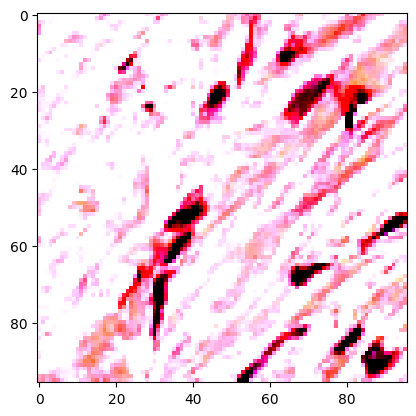

In [8]:
%matplotlib inline
lc00 = sample_0['local_crops'][0]
plt.imshow(einops.rearrange(lc00, 'c h w -> h w c'))

In [23]:
sampleset[768008]

DEBUG: pancan_tilesamples: __getitem__: index=768008, shard_idx=604, shard_lo=764134, shard_len=5624, shard_hi=769758, idx=3874


({'global_crops': [tensor([[[ 1.8037,  2.2147,  2.1975,  ...,  1.7180,  1.9407,  2.2147],
            [ 2.1975,  2.1975,  2.0092,  ...,  1.5468,  1.6667,  2.1804],
            [ 2.2147,  1.9749,  1.9064,  ...,  1.6153,  1.5468,  2.0434],
            ...,
            [ 0.0227,  0.2624,  0.6563,  ...,  2.1804,  2.1804,  2.1804],
            [ 0.1768,  0.1939,  0.4508,  ...,  2.1804,  2.1804,  2.1804],
            [ 0.1939,  0.0741,  0.3652,  ...,  2.1804,  2.1804,  2.1804]],
   
           [[ 0.9580,  1.4482,  1.7108,  ...,  0.3452,  0.8004,  1.2906],
            [ 1.5007,  1.5532,  1.2556,  ...,  0.2052,  0.4678,  1.0280],
            [ 1.3782,  0.8004,  0.7129,  ...,  0.2577,  0.2752,  0.8004],
            ...,
            [-1.0553, -0.8978, -0.6176,  ...,  2.3585,  2.2885,  2.2885],
            [-0.9328, -0.9503, -0.7227,  ...,  2.3235,  2.3235,  2.2885],
            [-0.9153, -1.0903, -0.8803,  ...,  2.2885,  2.2885,  2.3585]],
   
           [[ 1.6640,  2.1520,  2.3263,  ...,  1.245

# DATALOADER

In [4]:
dataloader = autopath.gigaq.dinov2.pipelines.dino_pancan_tile_dataloader('DINO_CPTAC_9802_TEST', batch_size=8)

INFO: _call_with_frames_removed: READ /mnt/labshare/PERSONAL/dmitry/dbx/autopath.pancan.tiles.PancanTileSplit/cf9175e9b1c53200cd9e3ca37325c37158779f33e7a9e809b2106935ecd13694/test_bag_indices/test_bag_indices.pt
INFO: _call_with_frames_removed: READ ['bag_lens'] from /mnt/labshare/PERSONAL/dmitry/dbx/autopath.pancan.tiles.PancanTileFold/0837698127de87d2efd389d7086b5c72804624b641ebab40227a165887d313f4/bag_lens.npz
DEBUG: autopath.pancan.tiles.PancanTileSet: Building dataset out of 73 bags
DEBUG: autopath.pancan.tiles.PancanTileSet: Computing _bag_bounds
DEBUG: autopath.pancan.tiles.PancanTileSet: self._n_bags=73, self._bag_bounds=array([  775,   972,  1855,  3284,  3916,  4469,  4764,  5034,  5893,
        6414, 10031, 10311, 12190, 12787, 12870, 13246, 13920, 14949,
       15374, 16737, 17397, 17672, 18100, 18728, 19382, 19801, 20709,
       21134, 24525, 24836, 28023, 30268, 30564, 32168, 32683, 36582,
       37268, 38433, 39213, 43998, 46338, 46580, 46607, 48247, 49600,
       51149,

In [5]:
try:
    display(len(dataloader))
except: 
    display(None)

None

In [6]:
import time
N = 10
for i, sample in enumerate(dataloader):
    if i >= N:
        break
    print(f"{i}-th sample")
    time.sleep(1)
print("Done")

DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=37712, bag_idx=37, bag_lo=37268, bag_len=1165, bag_hi=38433, idx=444
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=52474, bag_idx=48, bag_lo=52120, bag_len=1947, bag_hi=54067, idx=354
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=50387, bag_idx=45, bag_lo=49600, bag_len=1549, bag_hi=51149, idx=787
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=41400, bag_idx=39, bag_lo=39213, bag_len=4785, bag_hi=43998, idx=2187
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=49916, bag_idx=45, bag_lo=49600, bag_len=1549, bag_hi=51149, idx=316
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=47011, bag_idx=43, bag_lo=46607, bag_len=1640, bag_hi=48247, idx=404
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=50657, bag_idx=45, bag_lo=49600, bag_len=1549, bag_hi=51149, idx=1057
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=36896, bag_

In [7]:
def unnorm(t):
    return ((t-t.min())/(t.max()-t.min())*255).byte()

In [8]:
dl0 = next(iter(dataloader))

DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=37712, bag_idx=37, bag_lo=37268, bag_len=1165, bag_hi=38433, idx=444
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=52474, bag_idx=48, bag_lo=52120, bag_len=1947, bag_hi=54067, idx=354
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=50387, bag_idx=45, bag_lo=49600, bag_len=1549, bag_hi=51149, idx=787
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=41400, bag_idx=39, bag_lo=39213, bag_len=4785, bag_hi=43998, idx=2187
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=49916, bag_idx=45, bag_lo=49600, bag_len=1549, bag_hi=51149, idx=316
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=47011, bag_idx=43, bag_lo=46607, bag_len=1640, bag_hi=48247, idx=404
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=50657, bag_idx=45, bag_lo=49600, bag_len=1549, bag_hi=51149, idx=1057
DEBUG: autopath.pancan.tiles.PancanTileSet: __getitem__: index=36896, bag_

In [9]:
dl0.keys()

dict_keys(['collated_global_crops', 'collated_local_crops', 'collated_masks', 'mask_indices_list', 'masks_weight', 'upperbound', 'n_masked_patches'])

In [10]:
cgc0 = dl0['collated_global_crops']
display(len(cgc0))
display(cgc0[0].shape)
display(cgc0[0].dtype)

16

torch.Size([3, 224, 224])

torch.float16

In [11]:
ucgc0 = unnorm(cgc0)
display(ucgc0.shape)
display(ucgc0.dtype)

torch.Size([16, 3, 224, 224])

torch.uint8

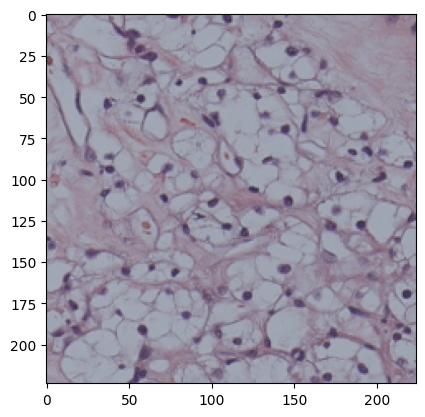

In [12]:
%matplotlib inline
plt.imshow(einops.rearrange(ucgc0[0], 'c h w -> h w c').numpy())